# PBRF — minimal curvature comparison

For a trained $\theta^s$ and a deleted training point $z$, compare the **influence
prediction** under each curvature $\hat G_M$ against the **PBRF retraining**
ground truth, over 40 points:

$$\widehat{\Delta\phi}_M(z)=\tfrac1N\,\nabla\phi_Q(\theta^s)^\top(\hat G_M+\lambda I)^{-1}\nabla\ell(z),
\qquad \Delta_{\mathrm{PBRF}}(z)=\phi_Q(\theta^b_{-z})-\phi_Q(\theta^s).$$

**Debug aids built in:** the table reports both Pearson and Spearman (GNH being
best-Pearson / worst-Spearman = conditioning, not a bug), and we check whether
the Kronecker methods are actually distinct from identity.

## Setup + config

In [15]:
import os

os.environ["JAX_ENABLE_X64"] = "1"
import sys
from pathlib import Path

PROJECT_ROOT = Path("/root/Hessian-Approximation-for-Toy-Models")
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))
import jax

jax.config.update("jax_enable_x64", True)
import jax.numpy as jnp, numpy as np, optax, pandas as pd, tempfile
from functools import partial
from jax.flatten_util import ravel_pytree
from scipy.stats import pearsonr, spearmanr

from src.config import (
    HessianApproximationMethod as HAM,
    LossType,
    PseudoTargetGenerationStrategy,
)
from src.utils.train import load_model_checkpoint, load_train_test_for_model
from src.utils.loss import get_loss, loss_wrapper_with_apply_fn
from src.hessians.collector import CollectorActivationsGradients
from src.hessians.computer.registry import HessianComputerRegistry
from src.hessians.utils.data import ModelContext
from src.utils.data.data import Dataset
from src.utils.influence import compute_per_example_flat_grads, compute_influence_matrix

# --- config ---
MODEL_DIR = PROJECT_ROOT / "experiments/outputs/models/digits/resnet_mlp_0a69ab6297da"
EPOCH = 100  # the regime we're focusing on
N_DELETED = 100
LAMBDA = 1e-3
SEED = 0
RETRAIN_EPOCHS = 100  # None -> base_epochs // 2
METHODS = [HAM.GNH, HAM.KFAC, HAM.EKFAC, HAM.SHAMPOO, HAM.ESHAMPOO, HAM.IDENTITY]
PSEUDO_STRATEGY = PseudoTargetGenerationStrategy.MCMC
RETRAIN_KEY = 7
print("jax", jax.__version__, "| x64:", jax.config.jax_enable_x64)

jax 0.8.2 | x64: True


## Load $\theta^s$ + data

In [16]:
params, model, model_config, metadata = load_model_checkpoint(
    str(MODEL_DIR), epoch=EPOCH
)
params = jax.tree.map(lambda x: jnp.asarray(x, jnp.float64), params)
train_ds, test_ds = load_train_test_for_model(str(MODEL_DIR))
loss_fn = get_loss(model_config.loss)

X_train, y_train = jnp.asarray(train_ds.inputs, jnp.float64), train_ds.targets
Xq, yq = jnp.asarray(test_ds.inputs, jnp.float64), test_ds.targets
flat_params_s, unravel = ravel_pytree(params)
N_TRAIN = int(X_train.shape[0])
EPS = 1.0 / N_TRAIN

_tr = model_config.training
RETRAIN_EPOCHS = (
    RETRAIN_EPOCHS if RETRAIN_EPOCHS is not None else max(1, _tr.epochs // 2)
)
RETRAIN_BATCH = _tr.batch_size
LR_PBRF = _tr.learning_rate / 10.0
print(
    f"epoch={EPOCH}  params={flat_params_s.size}  N_train={N_TRAIN}  "
    f"retrain={RETRAIN_EPOCHS}ep B={RETRAIN_BATCH} lr={LR_PBRF:g}"
)

epoch=100  params=2720  N_train=3823  retrain=100ep B=32 lr=0.0003


## Soft targets, deleted points, $\phi_Q$, per-example losses

In [17]:
soft_targets = jax.lax.stop_gradient(model.apply(params, X_train))
rng = np.random.RandomState(SEED)
deleted_idx = jnp.asarray(
    rng.choice(N_TRAIN, N_DELETED, replace=False), dtype=jnp.int32
)


def phi_Q_flat(fp):
    return loss_wrapper_with_apply_fn(model.apply, fp, unravel, loss_fn, Xq, yq)


if model_config.loss == LossType.CROSS_ENTROPY:

    def loss_per(f, y):
        return optax.softmax_cross_entropy_with_integer_labels(f, y)

    def breg_per(f, fs):
        fs = jax.lax.stop_gradient(fs)
        ps = jax.nn.softmax(fs, -1)
        return jnp.sum(
            ps * (jax.nn.log_softmax(fs, -1) - jax.nn.log_softmax(f, -1)), -1
        )
else:

    def loss_per(f, y):
        return jnp.mean((f - y) ** 2, -1)

    def breg_per(f, fs):
        return jnp.mean((f - jax.lax.stop_gradient(fs)) ** 2, -1)


phi0 = float(phi_Q_flat(flat_params_s))
print(f"phi_Q(theta^s) = {phi0:.6f}")

phi_Q(theta^s) = 0.328273


## PBRF ground truth

Minibatch SGD from $\theta^s$ for $K/2$ epochs on the proximal Bregman objective,
the deleted point masked per-example. `vmap`ed over the 40 points.

In [18]:
def pbrf_retrain(lam):
    opt = optax.sgd(LR_PBRF)
    nfull = N_TRAIN // RETRAIN_BATCH

    def one(t_idx):
        def bl(p, idx):
            f = model.apply(unravel(p), X_train[idx])
            is_t = (idx == t_idx).astype(f.dtype)
            c = (1.0 - is_t) * breg_per(f, soft_targets[idx]) + is_t * (
                -loss_per(f, y_train[idx])
            )
            return jnp.mean(c) + 0.5 * lam * jnp.sum((p - flat_params_s) ** 2)

        def ep(carry, ek):
            p, st = carry
            perm = jax.random.permutation(ek, N_TRAIN)[: nfull * RETRAIN_BATCH].reshape(
                nfull, RETRAIN_BATCH
            )

            def bs(c, idx):
                p, st = c
                g = jax.grad(bl)(p, idx)
                u, st = opt.update(g, st, p)
                return (optax.apply_updates(p, u), st), None

            (p, st), _ = jax.lax.scan(bs, (p, st), perm)
            return (p, st), None

        keys = jax.random.split(jax.random.PRNGKey(RETRAIN_KEY), RETRAIN_EPOCHS)
        (p, _), _ = jax.lax.scan(ep, (flat_params_s, opt.init(flat_params_s)), keys)
        return phi_Q_flat(p)

    return np.asarray(jax.jit(jax.vmap(one))(deleted_idx)) - phi0


delta_pbrf = pbrf_retrain(LAMBDA)
print(f"Delta_PBRF: mean={delta_pbrf.mean():+.3e}  std={delta_pbrf.std():.3e}")

Delta_PBRF: mean=-2.862e-06  std=1.636e-05


## Build curvatures + IF predictions

In [19]:
model_ctx = ModelContext.create(
    model=model, params=params, dataset=train_ds, loss_fn=loss_fn
)
_MODELCTX = {HAM.GNH, HAM.EXACT, HAM.BLOCK_HESSIAN}
collector_data = None
if any(m not in _MODELCTX for m in METHODS):
    collector_data = CollectorActivationsGradients(
        model=model,
        params=params,
        loss_fn=loss_fn,
        pseudo_target_strategy=PSEUDO_STRATEGY,
        pseudo_target_repetitions=1,
    ).collect(
        dataset=Dataset(inputs=X_train, targets=y_train),
        save_directory=tempfile.mkdtemp(),
        try_load=False,
        rng_key=jax.random.PRNGKey(42),
    )

computers = {}
for m in METHODS:
    cc = HessianComputerRegistry.get_compute_context(m, collector_data, model_ctx)
    computers[m] = HessianComputerRegistry.get_computer(
        m, cc, corr_context=collector_data
    ).build(base_directory=None)

query_grad = jax.grad(phi_Q_flat)(flat_params_s)
train_grads = compute_per_example_flat_grads(
    model, params, X_train[deleted_idx], y_train[deleted_idx], loss_fn
)
delta_if = {
    m: EPS
    * np.asarray(
        compute_influence_matrix(
            query_grad[None, :], train_grads, computers[m], damping=float(LAMBDA)
        )
    ).reshape(-1)
    for m in METHODS
}

INFO:2026-06-23 15:54:55,%f:collector.py:_generate_pseudo_targets:212: [PSEUDO-TARGETS] MCMC with 1 repetitions
INFO:2026-06-23 15:54:55,%f:collector.py:_run_collection_loop:294: [COLLECTION] MCMC: N=3823, k=1
INFO:2026-06-23 15:54:57,%f:collector.py:_teardown:335: [TEARDOWN] MCMC: activations (N=3823, ...), gradients (N=3823, ..., k=1)
INFO:2026-06-23 15:54:57,%f:collector.py:collect:150: Saving collected data to: /tmp/tmpeupnza7p
INFO:2026-06-23 15:54:57,%f:collector.py:save:374: Saved collected data manifest to: /tmp/tmpeupnza7p
INFO:2026-06-23 15:55:01,%f:influence.py:compute_influence_matrix:77: Computing IHVPs: 1 test × 2720 params
INFO:2026-06-23 15:55:01,%f:influence.py:compute_influence_matrix:77: Computing IHVPs: 1 test × 2720 params
INFO:2026-06-23 15:55:01,%f:influence.py:compute_influence_matrix:77: Computing IHVPs: 1 test × 2720 params
INFO:2026-06-23 15:55:01,%f:influence.py:compute_influence_matrix:77: Computing IHVPs: 1 test × 2720 params
INFO:2026-06-23 15:55:01,%f:in

## Result + debug checks

In [20]:
rows = []
for m in METHODS:
    p, s = pearsonr(delta_if[m], delta_pbrf)[0], spearmanr(delta_if[m], delta_pbrf)[0]
    rows.append(
        dict(
            method=m.value,
            pbrf_P=float(p),
            pbrf_S=float(s),
            ratio=float(np.linalg.norm(delta_if[m]) / np.linalg.norm(delta_pbrf)),
        )
    )
res = pd.DataFrame(rows)
pd.set_option("display.float_format", lambda v: f"{v:+.3f}")
print(f"lambda={LAMBDA:g}  epoch={EPOCH}\n")
print(res.to_string(index=False))

# DEBUG 1: are the non-GNH methods actually distinct, or all == identity?
print("\n[debug] max |delta_if[m] - delta_if[identity]| (0 => identical to identity):")
base = delta_if[HAM.IDENTITY]
for m in METHODS:
    print(f"  {m.value:9s} {np.max(np.abs(delta_if[m] - base)):.3e}")

# DEBUG 2: GNH best-Pearson / worst-Spearman => conditioning, not a bug.
g = res[res.method == "gnh"].iloc[0]
print(
    f"\n[debug] GNH: Pearson rank={int((res.pbrf_P > g.pbrf_P).sum()) + 1}/{len(res)}  "
    f"Spearman rank={int((res.pbrf_S > g.pbrf_S).sum()) + 1}/{len(res)}  "
    f"(best-P/worst-S => exact-inverse conditioning at small lambda, not a bug)"
)

lambda=0.001  epoch=100

  method  pbrf_P  pbrf_S    ratio
     gnh  +0.643  +0.353   +9.103
    kfac  +0.882  +0.802  +71.526
   ekfac  +0.804  +0.848  +82.713
 shampoo  +0.961  +0.805 +125.717
eshampoo  +0.974  +0.807 +149.193
identity  +0.868  +0.767   +0.985

[debug] max |delta_if[m] - delta_if[identity]| (0 => identical to identity):
  gnh       1.406e-03
  kfac      9.512e-03
  ekfac     1.119e-02
  shampoo   1.465e-02
  eshampoo  1.867e-02
  identity  0.000e+00

[debug] GNH: Pearson rank=6/6  Spearman rank=6/6  (best-P/worst-S => exact-inverse conditioning at small lambda, not a bug)


## Figure-1-style scatter — IF prediction vs PBRF (per curvature)

Like Fig. 1 of the paper. **x = the iHVP-based influence estimate**
$\tfrac1N[(\hat G_M+\lambda I)^{-1}\nabla\phi_Q]^\top\nabla\ell(z)$ (i.e.
`delta_if[m]` — the iHVP $(\hat G_M+\lambda I)^{-1}\nabla\phi_Q$ dotted with the
deleted-point gradient), **y = PBRF retraining ground truth** $\Delta\phi_Q$.
One panel per curvature. Points on the dashed $y=x$ line = well-calibrated;
off-diagonal points are the outliers. Reuses the arrays above — no retraining.

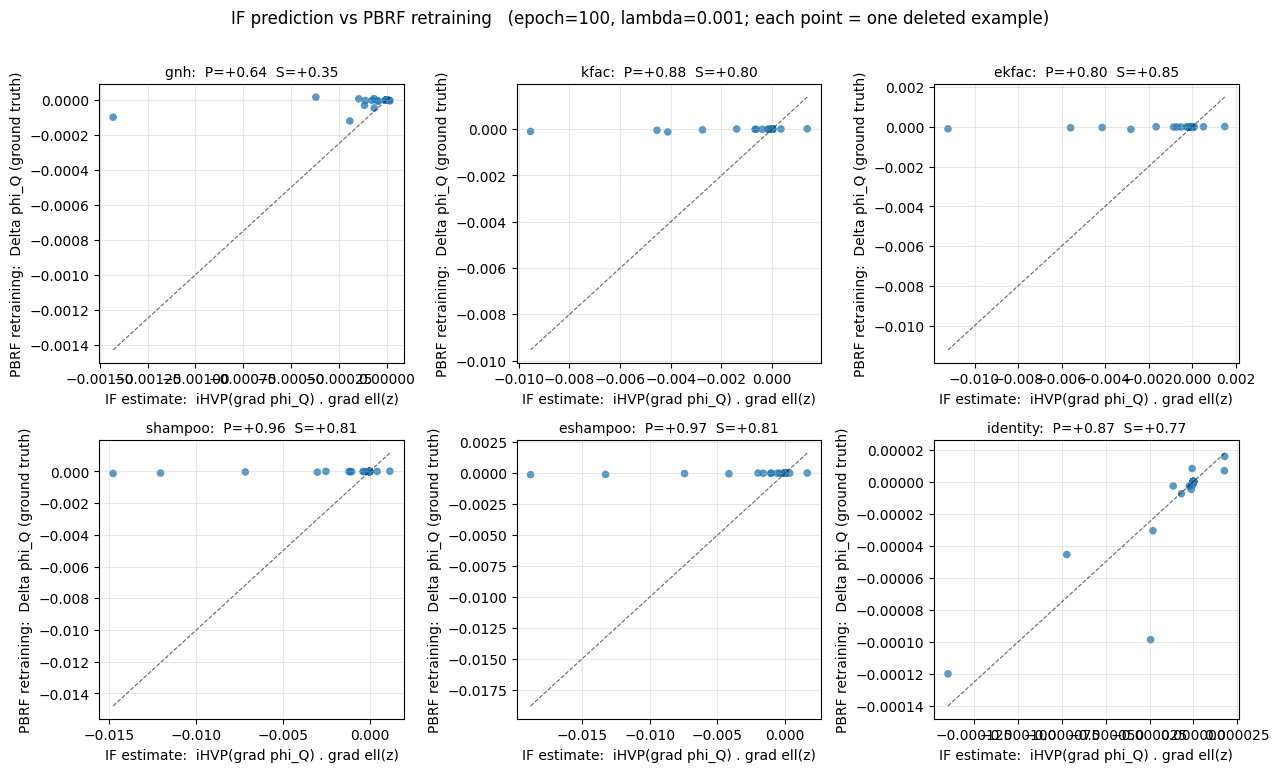

In [21]:
import matplotlib.pyplot as plt

ncol = 3
nrow = -(-len(METHODS) // ncol)
fig, axes = plt.subplots(nrow, ncol, figsize=(4.3 * ncol, 3.8 * nrow))
for ax, m in zip(np.ravel(axes), METHODS):
    pred, gt = delta_if[m], delta_pbrf
    p, s = pearsonr(pred, gt)[0], spearmanr(pred, gt)[0]
    ax.scatter(pred, gt, s=30, alpha=0.75, edgecolor="none")
    lo = float(min(pred.min(), gt.min()))
    hi = float(max(pred.max(), gt.max()))
    ax.plot([lo, hi], [lo, hi], "k--", lw=0.8, alpha=0.6)  # y = x : perfect calibration
    ax.set_title(f"{m.value}:  P={p:+.2f}  S={s:+.2f}", fontsize=10)
    ax.set_xlabel("IF estimate:  iHVP(grad phi_Q) . grad ell(z)")
    ax.set_ylabel("PBRF retraining:  Delta phi_Q (ground truth)")
    ax.grid(alpha=0.3)
for ax in np.ravel(axes)[len(METHODS) :]:
    ax.axis("off")
fig.suptitle(
    f"IF prediction vs PBRF retraining   (epoch={EPOCH}, lambda={LAMBDA:g}; "
    f"each point = one deleted example)",
    y=1.01,
)
fig.tight_layout()
plt.show()